In [72]:
import sqlite3
import pandas as pd


# Подключаемся к базе данных
conn = sqlite3.connect("./olist.sqlite")

# Загружаем таблицу заказов
orders = pd.read_sql_query("SELECT * FROM orders", conn)








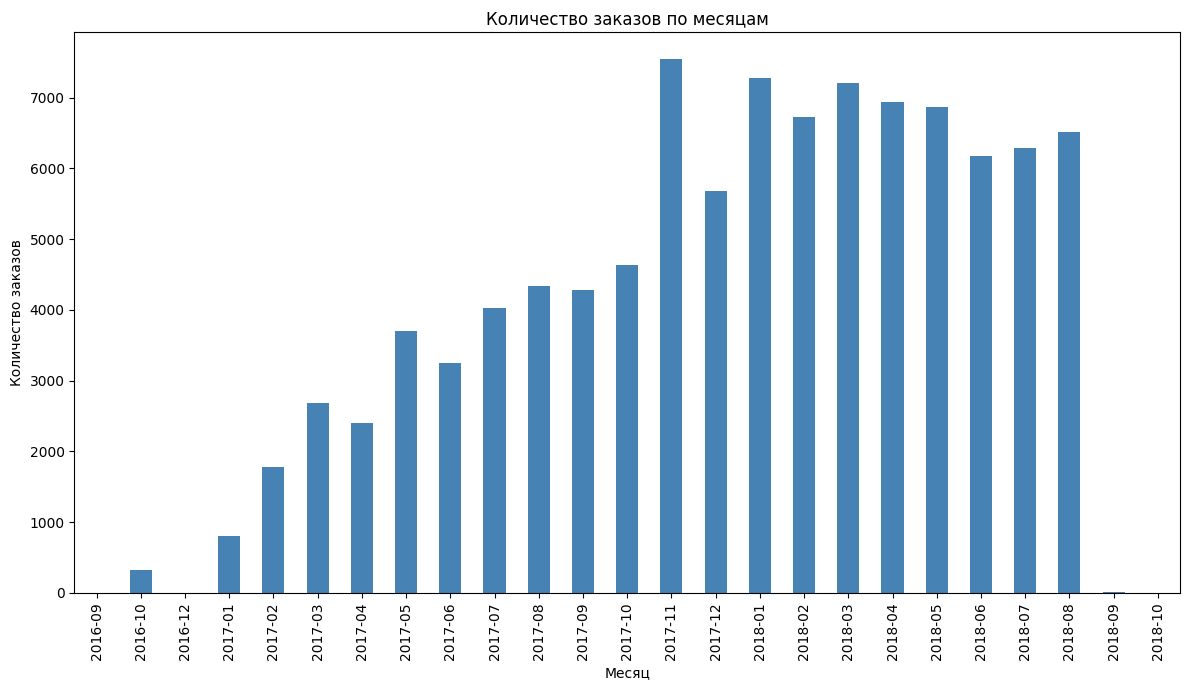

Топ 5 дней по количеству заказов:
day
2017-11-24    1176
2017-11-25     499
2017-11-27     403
2017-11-26     391
2017-11-28     380
dtype: int64


In [73]:
import matplotlib.pyplot as plt

# Загружаем заказы с датами
orders = pd.read_sql("SELECT * FROM orders", conn)

# Превращаем дату в правильный формат
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# Добавляем колонку "месяц"
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

# Считаем количество заказов по месяцам
monthly = orders.groupby("month").size()

# Строим график
monthly.plot(kind="bar", figsize=(12,7), color="steelblue")
plt.title("Количество заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()


# Смотрим топ 5 самых активных дней
orders["day"] = orders["order_purchase_timestamp"].dt.date
top_days = orders.groupby("day").size().sort_values(ascending=False).head(5)
print("Топ 5 дней по количеству заказов:")
print(top_days)
